Cameron Barlow

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Question 1**

In [2]:
foreign_gifts = pd.read_csv('ForeignGifts_edu.csv')

In [3]:
foreign_gifts.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


**Question 2**

In [4]:
foreign_gifts['Gift Type'].unique()

<StringArray>
['Monetary Gift', 'Contract', 'Real Estate']
Length: 3, dtype: str

In [5]:
foreign_gifts['Gift Type'].value_counts()

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

In [6]:
foreign_gifts[['Foreign Gift Amount', 'Gift Type']].groupby('Gift Type').sum()

,Foreign Gift Amount
Gift Type,
Contract,10809974431
Monetary Gift,5775853163
Real Estate,14687920


In [7]:
foreign_gifts[['Foreign Gift Amount', 'Gift Type']].groupby('Gift Type').mean()

,Foreign Gift Amount
Gift Type,
Contract,6.257945e+05
Monetary Gift,5.281504e+05
Real Estate,1.335265e+06


In first investigating the different types of gifts, there are 3 unique gift types -- Monetary Gift, Contract, and Real Estate. I next looked at how much money and how often each type of gift appeared. Gift type of Contract was the most common type of gift, with Real Estate being the least common type of gift seen. In terms of the money, Contract gets the most amount of money and real estate gets the least amount in total, but this could be influenced by just how many of these types of gifts are seen in the data. In looking at the average of the money of these gifts, real estate actually had the most amount of money spent on it.

**Question 3**

***Part 1*** Which country gives the most money in total?

In [8]:
money_by_country = foreign_gifts[['Foreign Gift Amount', 'Country of Giftor']].groupby('Country of Giftor').sum().sort_values(by='Foreign Gift Amount', ascending=False)

In [9]:
money_by_country.head(10)

,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


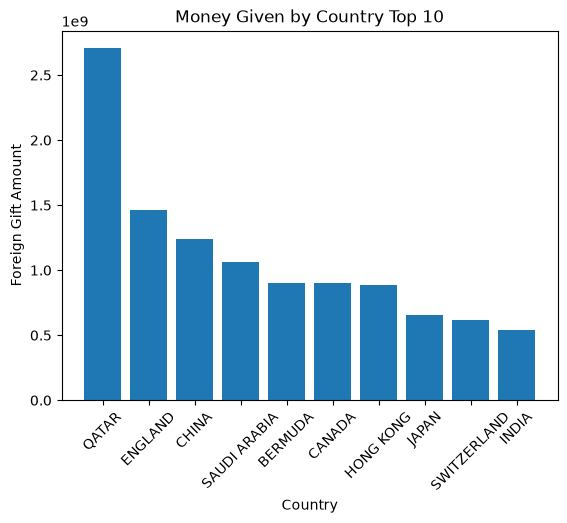

In [10]:
money_by_country_top_10 = money_by_country.head(10)
plt.bar(money_by_country_top_10.index, money_by_country_top_10['Foreign Gift Amount'])

plt.title('Money Given by Country Top 10')
plt.xlabel('Country')
plt.ylabel('Foreign Gift Amount')
plt.xticks(rotation=45)

plt.show()

As seen from the histogram above, Qatar gives the most money in total.

***Part 2*** Which country initiates the most gifts by count? 

In [11]:
gifts_by_country = foreign_gifts['Country of Giftor'].value_counts()

In [12]:
gifts_by_country.head(10)

Country of Giftor
ENGLAND         3655
CHINA           2461
CANADA          2344
JAPAN           1896
SWITZERLAND     1676
SAUDI ARABIA    1610
FRANCE          1437
GERMANY         1394
HONG KONG       1080
SOUTH KOREA      811
Name: count, dtype: int64

The country that initiates the most gifts by count is England.

***Part 3*** Which country gives the largest gifts on average?

In [13]:
money_avg_by_country = foreign_gifts[['Foreign Gift Amount', 'Country of Giftor']].groupby('Country of Giftor').mean().sort_values(by='Foreign Gift Amount', ascending=False)

In [14]:
money_avg_by_country.head(10)

,Foreign Gift Amount
Country of Giftor,
BERMUDA,7.688837e+06
ECUADOR,3.985140e+06
QATAR,3.905109e+06
ANTIGUA,3.435545e+06
JERSEY,3.064589e+06
MOROCCO,2.740214e+06
RUSSIA,2.025462e+06
GUERNSEY,1.750000e+06
IRAQ,1.665520e+06


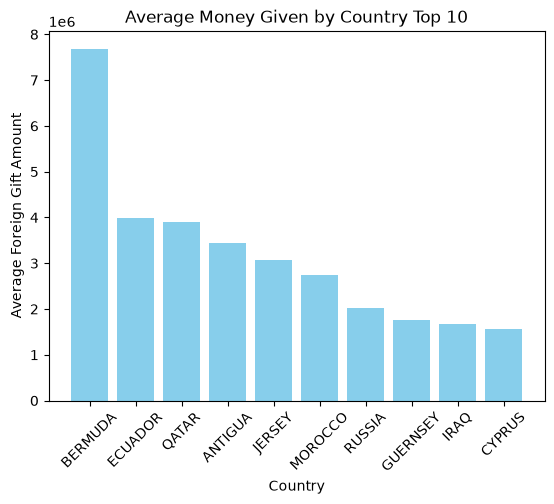

In [15]:
money_avg_by_country_top_10 = money_avg_by_country.head(10)
plt.bar(money_avg_by_country_top_10.index, money_avg_by_country_top_10['Foreign Gift Amount'], color='skyblue')

plt.title('Average Money Given by Country Top 10')
plt.xlabel('Country')
plt.ylabel('Average Foreign Gift Amount')
plt.xticks(rotation=45)

plt.show()

Bermuda gives the largest gifts on average according to the data.

**Part 4: Which institution receive the most money in total?**

In [16]:
money_by_college = foreign_gifts[['Foreign Gift Amount', 'Institution Name']].groupby('Institution Name').sum().sort_values(by='Foreign Gift Amount', ascending=False)
money_by_college.head(10)

,Foreign Gift Amount
Institution Name,
Carnegie Mellon University,1477922504
Cornell University,1289937761
Harvard University,954803610
Massachusetts Institute of Technology,859071692
Yale University,613441311
Texas A&M University,521455050
Johns Hopkins University,502409595
Northwestern University,402316221
Georgetown University,379950511


Carnegie Mellon University is the institution that received the most money in total.

**Part 5: Which institution receive the greatest number of gifts by count?**

In [17]:
gifts_by_institution = foreign_gifts['Institution Name'].value_counts()

In [18]:
gifts_by_institution.head(20)

Institution Name
University of California, Los Angeles          3916
California Institute of Technology             2502
Columbia University in the City of New York    1127
Ohio State University (The)                    1014
Johns Hopkins University                        899
University of Michigan - Ann Arbor              715
Stanford University                             668
Cornell University                              653
University of Pennsylvania                      625
Massachusetts Institute of Technology           582
Yale University                                 550
Harvard University                              453
University of Colorado Denver                   436
University of Chicago (The)                     401
Arizona State University                        400
University of California, Berkeley              394
Colorado State University                       379
University of Texas at Austin                   377
Texas A&M University                           

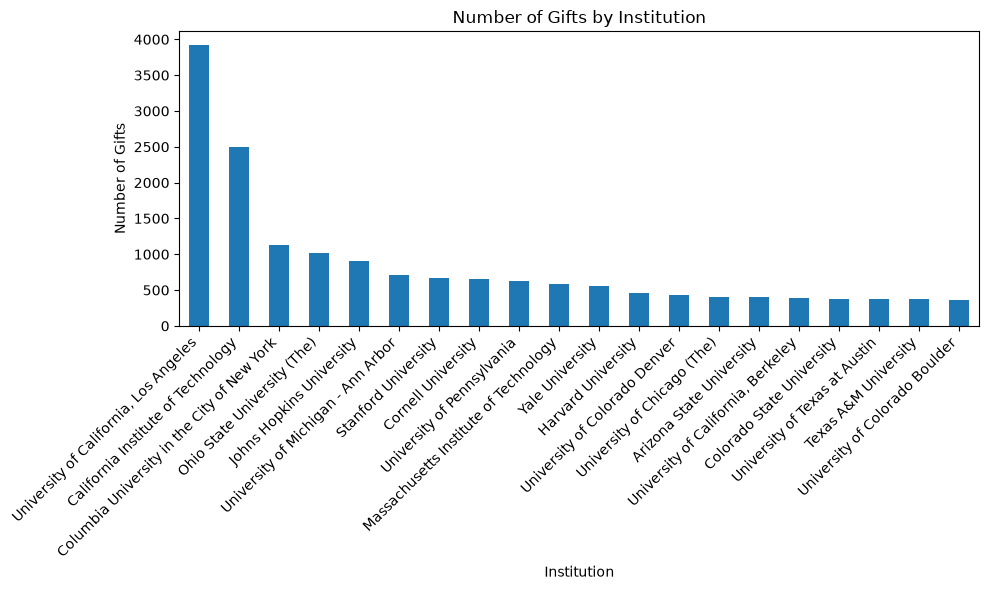

In [19]:
gifts_by_institution_top_20 = gifts_by_institution.head(20)
gifts_by_institution_top_20.plot(kind='bar', figsize=(10, 6))

plt.title('Number of Gifts by Institution')
plt.xlabel('Institution')
plt.ylabel('Number of Gifts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The institution that recieved the greatest amount of gifts by count is University of California, Los Angeles.

**Part 6: What is the average amount each university receives? Median amount? If they are different why?**

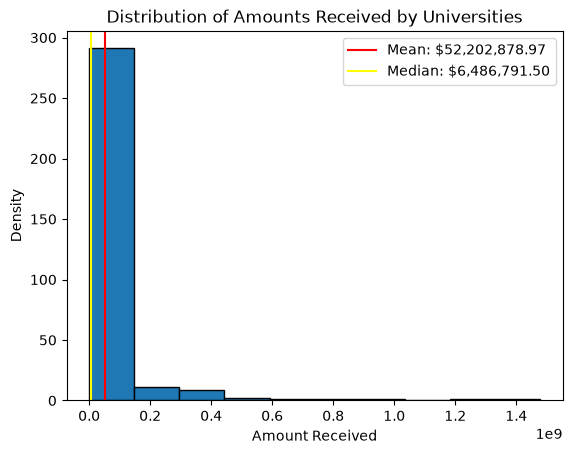

In [20]:
university_amounts = foreign_gifts.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
mean_amount = university_amounts.mean()
median_amount = university_amounts.median()


plt.hist(university_amounts.values,edgecolor='black')

plt.axvline(mean_amount, color='red',label=f'Mean: ${mean_amount:,.2f}')

plt.axvline(median_amount, color='yellow',label=f'Median: ${median_amount:,.2f}')

plt.title('Distribution of Amounts Received by Universities')
plt.xlabel('Amount Received')
plt.ylabel('Density')
plt.legend()

plt.show()

The average amount each university receives is 52,202,878.87 dollars, while the median amount is 6,486,791.50. These values are different because the amounts are very right skewed, so the average is much higher than the mdedian. The mean is much more sensitive to larger data points than the median.

**Question 7: What is the largest flow of a single country to a single institution?**

In [21]:
table = pd.crosstab(foreign_gifts['Institution Name'],foreign_gifts['Country of Giftor'],values=foreign_gifts['Foreign Gift Amount'],aggfunc='sum')

largest_flow = table.stack().idxmax()
largest_amount = table.stack().max()

largest_flow, largest_amount

(('Cornell University', 'QATAR'), np.float64(1018473315.0))

The largest flow of a single country to a single institution is Qatar to Cornell University.

**Part 8: Which are the top giftors to US academic institutions?**

In [22]:
money_by_college = foreign_gifts[['Foreign Gift Amount', 'Giftor Name']].groupby('Giftor Name').sum().sort_values(by='Foreign Gift Amount', ascending=False)
money_by_college.head(10)

,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


Qatar Foundation, Anonymous, Saudi Arabian Cultural Mission, and the Church of Jesus Christ of LDS are among the top giftors to US academic institutions.